## **Reading Dataset**

In [1]:
# import pandas for data handling
import pandas as pd

In [2]:
# read the csv file into dataframe
df_reviews = pd.read_csv("IMDB Dataset.csv")

In [3]:
# show dataframe
df_reviews

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [4]:
# take a sample of 10000 rows to make processing faster and get imbalance data
# 9000 positives
df_positive = df_reviews[df_reviews['sentiment'] == 'positive'][:9000]
# 1000 negative
df_negative = df_reviews[df_reviews['sentiment'] == 'negative'][:1000]

In [5]:
# postive dataset
print(df_positive)

# negative dataset
print(df_negative)

                                                  review sentiment
0      One of the other reviewers has mentioned that ...  positive
1      A wonderful little production. <br /><br />The...  positive
2      I thought this was a wonderful way to spend ti...  positive
4      Petter Mattei's "Love in the Time of Money" is...  positive
5      Probably my all-time favorite movie, a story o...  positive
...                                                  ...       ...
18187  The Sea Is Watching has been made from an orig...  positive
18188  I used to watch this show when I was a little ...  positive
18189  John Leguizamo's one man show is both funnier ...  positive
18192  in a not so conventional sense of the word.<br...  positive
18195  This movie brings back so many memories for me...  positive

[9000 rows x 2 columns]
                                                 review sentiment
3     Basically there's a family where a little boy ...  negative
7     This show was an amazing, fresh &

In [6]:
# concating both positive and negative dataset (imbalance dataset)
df_reviews_imb = pd.concat([df_positive, df_negative])
df_reviews_imb

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
...,...,...
2000,Stranded in Space (1972) MST3K version - a ver...,negative
2005,"I happened to catch this supposed ""horror"" fli...",negative
2007,waste of 1h45 this nasty little film is one to...,negative
2010,Warning: This could spoil your movie. Watch it...,negative


In [7]:
df_reviews_imb.value_counts('sentiment')

,count
sentiment,
positive,9000
negative,1000


## **Dealing with Imbalance Classes**

<Axes: xlabel='sentiment'>

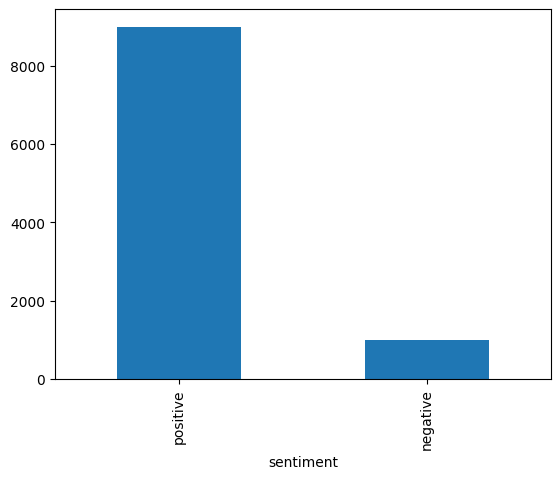

In [8]:
# make a barplot to show how data is distributed
df_reviews_imb.value_counts('sentiment').plot(kind='bar')

### **Balancing Data with .sample()**

In [9]:
# length of positive and negative dataset
length_positive = len(df_reviews_imb[df_reviews_imb['sentiment'] == 'positive'])
print(length_positive)
length_negative = len(df_reviews_imb[df_reviews_imb['sentiment'] == 'negative'])
print(length_negative)

9000
1000


In [10]:
# take a random sample of positive reviews (same size as negative reviews for balance)
df_reviews_positive = df_reviews_imb[df_reviews_imb['sentiment'] == 'positive'].sample(length_negative)

# select all negative reviews (no sampling, take full set)
df_reviews_negative = df_reviews_imb[df_reviews_imb['sentiment'] == 'negative']

In [11]:
# concating both positive and negative dataset (balance dataset)
df_reviews_bal = pd.concat([df_reviews_positive, df_reviews_negative])
df_reviews_bal

,review,sentiment
14812,Orson Welles manages to knock me on my ass wit...,positive
1409,Feels like an impressionistic film; if there i...,positive
16445,"I really enjoyed ""Random Hearts"". It was shock...",positive
17740,Definitely one of the most witty and twisted w...,positive
17035,"""World's Finest"" is an unique project. It's a ...",positive
...,...,...
2000,Stranded in Space (1972) MST3K version - a ver...,negative
2005,"I happened to catch this supposed ""horror"" fli...",negative
2007,waste of 1h45 this nasty little film is one to...,negative
2010,Warning: This could spoil your movie. Watch it...,negative


In [12]:
# resetting index of the dataset
df_reviews_bal.reset_index(drop=True, inplace=True)
df_reviews_bal

,review,sentiment
0,Orson Welles manages to knock me on my ass wit...,positive
1,Feels like an impressionistic film; if there i...,positive
2,"I really enjoyed ""Random Hearts"". It was shock...",positive
3,Definitely one of the most witty and twisted w...,positive
4,"""World's Finest"" is an unique project. It's a ...",positive
...,...,...
1995,Stranded in Space (1972) MST3K version - a ver...,negative
1996,"I happened to catch this supposed ""horror"" fli...",negative
1997,waste of 1h45 this nasty little film is one to...,negative
1998,Warning: This could spoil your movie. Watch it...,negative


In [13]:
df_reviews_bal.value_counts('sentiment')

,count
sentiment,
negative,1000
positive,1000


### **Balancing Data with RandomUnderSampler**

In [14]:
# import RandomUnderSampler to balance datasets by undersampling the majority class
from imblearn.under_sampling import RandomUnderSampler

# create a RandomUnderSampler object (with random_state=0 for reproducibility)
rus = RandomUnderSampler(random_state=0)

# apply undersampling that returns balanced reviews (x) and sentiments (y)
df_reviews_bal, df_reviews_bal['sentiment'] = rus.fit_resample(
    df_reviews_imb[['review']],       # feature column
    df_reviews_imb['sentiment'])      # target column

In [15]:
df_reviews_imb.value_counts('sentiment')

,count
sentiment,
positive,9000
negative,1000


In [16]:
df_reviews_bal.value_counts('sentiment')

,count
sentiment,
negative,1000
positive,1000


## **Splitting Data into train & test**

In [17]:
# import train_test_split to split datasets into training and testing sets
from sklearn.model_selection import train_test_split

# split balanced dataset: 67% train & 33% train (random_state=42 for reproducibility)
train, test = train_test_split(df_reviews_bal, test_size=0.33, random_state=42)

In [18]:
# split training data into features (reviews) and labels (sentiments)
train_x, train_y = train['review'], train['sentiment']

# split testing data into features (reviews) and labels (sentiments)
test_x, test_y = test['review'], test['sentiment']

In [19]:
print(train_y.value_counts())
print(test_y.value_counts())

sentiment
negative    675
positive    665
Name: count, dtype: int64
sentiment
positive    335
negative    325
Name: count, dtype: int64


## **Text Representation (Bag of Words)**

### **Count Vectorizer**

In [20]:
# import CountVectorizer to convert text into word count vectors
from sklearn.feature_extraction.text import CountVectorizer

# sample text data
text = ["I love writing code in Python. I love Python code",
        "I hate writing code in Java. I hate Java code"]

# create dataframe with reviews and text
df = pd.DataFrame({'review': ['review1', 'review2'], 'text': text})

# create CountVectorizer (removes common English stopwords)
cv = CountVectorizer(stop_words='english')

# fit CountVectorizer on text data and transform into word cv matrix
cv_matrix = cv.fit_transform(df['text'])

In [21]:
# convert cv_matrix (sparse) into dataframe for readability
# rows: review names, columns: unique worrds (features), values: word counts
df_dtm = pd.DataFrame(cv_matrix.toarray(),      # convert sparse matrix to dense array
                      index=df['review'].values,      # set review IDs as row index
                      columns=cv.get_feature_names_out()      # set words as column names
                      )

In [22]:
# show the document-term matrix (word counts for each review)
df_dtm

,code,hate,java,love,python,writing
review1,2,0,0,2,2,1
review2,2,2,2,0,0,1


### **Tfidf**

In [23]:
# import TfidfVectorizer to convert text into TF-IDF weighted features
from sklearn.feature_extraction.text import TfidfVectorizer

# sample text data
text = ["I love writing code in Python. I love Python code",
        "I hate writing code in Java. I hate Java code"]

# create dataframe with reviews and text
df = pd.DataFrame({'review': ['review1', 'review2'], 'text': text})

# create TF-IDF vectorizer (removes english stopwords, no normalization applied)
tfidf = TfidfVectorizer(stop_words='english', norm=None)

# fit TF-IDF on text data and transform into a TF-IDF matrix
tfidf_matrix = tfidf.fit_transform(df['text'])

In [24]:
# convert tfidf_matrix (sparse) into dataframe for readability
# rows: review names, columns: unique worrds (features), values: word counts
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(),      # convert sparse matrix to dense array
                      index=df['review'].values,      # set review IDs as row index
                      columns=tfidf.get_feature_names_out()      # set words as column names
                      )

In [25]:
# show the document-term matrix (word counts for each review)
df_tfidf

,code,hate,java,love,python,writing
review1,2.0,0.00000,0.00000,2.81093,2.81093,1.0
review2,2.0,2.81093,2.81093,0.00000,0.00000,1.0


## **Turning our Text Data into Numerical Vectors**

In [26]:
# import TfidfVectorizer to convert text into TF-IDF weighted features
from sklearn.feature_extraction.text import TfidfVectorizer

# create TF-IDF vectorizer (removes common english stopwords)
tfidf = TfidfVectorizer(stop_words='english')

# fit vectorizer on training reviews and transform them into TF-IDF matrix
train_x_vector = tfidf.fit_transform(train_x)

In [27]:
# transform test reviews into TF-IDF matrix using the same fitted vectorizer
test_x_vector = tfidf.transform(test_x)

In [28]:
train_x_vector

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 118834 stored elements and shape (1340, 20625)>

In [29]:
test_x_vector

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 53486 stored elements and shape (660, 20625)>

In [30]:
# convert sparse TF-IDF matrix of training data into a dataframe
pd.DataFrame.sparse.from_spmatrix(
    train_x_vector,       # sparse matrix
    index=train_x.index,      # row labels
    columns=tfidf.get_feature_names_out()     # column labels (words)
    )

,00,000,007,01pm,02,04,08,10,100,1000,...,zooming,zooms,zues,zzzzzzzzzzzzzzzzzz,æon,élan,émigré,ísnt,ïn,ünfaithful
144,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1839,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
16588,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
742,0,0,0,0,0,0,0,0.042791,0,0,...,0,0,0,0,0,0,0,0,0,0
9464,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10644,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
16133,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1739,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2443,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## **Model Selection**

### **Support Vector Machines (SVM)**

In [31]:
# import support vector classifier for text classification or other classification tasks
from sklearn.svm import SVC

# create SVM classifier with linear kernel
svc = SVC(kernel='linear')

# train the SVM model on TF-IDF features and target labels
svc.fit(train_x_vector, train_y)

SVC(kernel='linear')

In [32]:
# predict sentiment of new reviews using the trained SVM model
print(svc.predict(tfidf.transform(['A good movie'])))
print(svc.predict(tfidf.transform(['An excellent movie'])))
print(svc.predict(tfidf.transform(['I did not like this movie at all I gave this movie away'])))

['positive']
['positive']
['negative']


### **Decision Tree**

In [33]:
# import decision tree classifier for classification tasks (e.g., predicting sentiment)
from sklearn.tree import DecisionTreeClassifier

# create a decision tree classifier
dec_tree = DecisionTreeClassifier()

# train the decision tree on TF-IDF features and target labels
dec_tree.fit(train_x_vector, train_y)


DecisionTreeClassifier()

### **Naive Bayes**

In [34]:
# import gaussian naive bayes classifier for classification tasks (e.g., sentiment analysis)
from sklearn.naive_bayes import GaussianNB

# create a gaussian naive bayes model
gnb = GaussianNB()

# train the model on TF-IDF features (converted to dense array) and target labels
gnb.fit(train_x_vector.toarray(), train_y)


GaussianNB()

### **Logistic Regression**

In [35]:
# import logistic regression classifier for classification tasks (e.g., sentiment analysis)
from sklearn.linear_model import LogisticRegression

# create a logistic regression model
log_reg = LogisticRegression()

# train the model on TF-IDF features and target labels
log_reg.fit(train_x_vector, train_y)

LogisticRegression()

## **Model Evaluation**

### **Confusion Matrix**

In [36]:
# import confusion matrix function to evaluate classification performance
from sklearn.metrics import confusion_matrix

# calculate confusion matrix for SVM predictions on test data
# rows: actual labels, columns: predicted labels
confusion_matrix(
    test_y,     # true labels
    svc.predict(test_x_vector),     # predicted labels from SVM
    labels=['positive', 'negative']     # order of labels in the matrix
)

array([[290,  45],
       [ 60, 265]])

### **Mean Accuracy**

In [37]:
# calculate and print accuracy of all models on the test set

# SVM model accuracy
print(svc.score(test_x_vector, test_y))

# decision tree accuracy
print(dec_tree.score(test_x_vector, test_y))

# gaussian naive bayes accuracy (requires dense array)
print(gnb.score(test_x_vector.toarray(), test_y))

# logistic regression accuracy
print(log_reg.score(test_x_vector, test_y))

# Note: model.score(X, y) returns the mean accuracy of the model on the given test data

0.8409090909090909
0.6681818181818182
0.6348484848484849
0.8303030303030303


### **F1 Score**

In [38]:
# import f1_score to evaluate model performance (harmonic mean of precision and recall)
from sklearn.metrics import f1_score

# calculate F1 score for SVM predictions on test data for each class separately
f1_score(
    test_y,     # true labels
    svc.predict(test_x_vector),     # predicted labels from SVM
    labels=['positive', 'negative'],      # specify label order
    average=None      # return F1 score for each class separately
)

array([0.84671533, 0.83464567])

### **Classificatioon Report**

In [39]:
# import classification report to get detailed metrics (precision, recall, F1-score) for each class
from sklearn.metrics import classification_report

# print classification report for SVM predictions on the test data
print(
    classification_report(
        test_y,     # true labels
        svc.predict(test_x_vector),     # predicted labels from SVM
        labels=['positive', 'negative']     # specify label order
    )
)

              precision    recall  f1-score   support

    positive       0.83      0.87      0.85       335
    negative       0.85      0.82      0.83       325

    accuracy                           0.84       660
   macro avg       0.84      0.84      0.84       660
weighted avg       0.84      0.84      0.84       660



## **Tunning the Model**

### **GridSearchCV**

In [40]:
# import GridSearchCV to perform hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# define hyperparameter grid for SVM
parameters = {'C': [1, 4, 8, 16, 32],     # Regularization parameter
              'kernel': ['linear', 'rbf']}      # Kernel types to try

# create SVM classifier
svc = SVC()

# create GridSearchCV object (5-fold cross-validation)
svc_grid = GridSearchCV(svc, parameters, cv=5)

# fit GridSearchCV on training data to find the best hyperparameters
svc_grid.fit(train_x_vector, train_y)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [1, 4, 8, 16, 32], 'kernel': ['linear', 'rbf']})

In [41]:
# show the best hyperparameters found by GridSearchCV for the SVM model
svc_grid.best_params_

{'C': 1, 'kernel': 'linear'}

In [42]:
# show the best SVM model (estimator) found by GridSearchCV with optimal hyperparameters
svc_grid.best_estimator_

SVC(C=1, kernel='linear')